In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
os.chdir('..')

In [3]:
import torch
from sklearn.model_selection import train_test_split
from fq_model.fq_tsk_knn_reg import FQ_regression
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, mean_squared_error
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [4]:
from regression.cal_house.cal_housing import CalHousing
X, y = CalHousing().get_data()

In [5]:
X.std(axis=0)

array([0.19955467, 0.22702395, 0.2468921 , 0.05557801, 0.06539025,
       0.03176044, 0.06286628, 0.13098059, 0.35502503])

In [6]:
y.std()

0.2380048790064407

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print(device)
test_size=0.2
batch_size=20
random_state=17
num_epochs=20
rules=10
lr=0.0001

cuda


In [21]:
train_loss = []
test_loss = []

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.5,
                                                    random_state=random_state)
    
out_size = 1
print('out_size', out_size)
model = FQ_regression(in_features=X.shape[1],
                      rules=rules,
                      out_features=out_size,
                      device=device).to(device)

model._rule_initialization(X_train, y_train)


X_train_eval = X_train
X_test_eval = X_test
y_train_eval = y_train
y_test_eval = y_test

X_train = torch.Tensor(X_train).to(device)
X_test = torch.Tensor(X_test).to(device)
y_train = torch.Tensor(y_train).to(device)
y_test = torch.Tensor(y_test).to(device)


# Initialize and move model to GPU

# Initialize Adam optimizer
optimizer = optim.RMSprop(model.parameters(), lr=lr)

# Store initial parameters
initial_params = {name: param.clone().detach() for name, param in model.named_parameters()}


for epoch in range(num_epochs):
    model.train()
    for i in range(0, len(X_train), batch_size):
    # for i in range(1):
        optimizer.zero_grad()
        batch_X, batch_y = X_train[i:i+batch_size], y_train[i:i+batch_size]
        outputs = model(batch_X)
        mse_loss = F.mse_loss(outputs, batch_y)
        total_loss = mse_loss  
        total_loss.backward()
        # print(model.tt.grad[0][0][0])
        optimizer.step()

    model.eval()
    with torch.no_grad():
        outputs = model(X_test).cpu()
        mse_loss = mean_squared_error(y_test_eval, outputs, squared=False)
        total_loss = mse_loss
        test_loss.append(total_loss.item())
        #####
        outputs = model(X_train).cpu()
        mse_loss = mean_squared_error(y_train_eval, outputs, squared=False)
        total_loss = mse_loss
        train_loss.append(total_loss.item())


# train_loss = np.sqrt(train_loss)
# test_loss = np.sqrt(test_loss)

# Calculate and print the average accuracy across all folds
min_RMSE = min(test_loss)
print("minimum test RMSE:", min_RMSE)
min_RMSE = min(train_loss)
print("minimum train RMSE:", min_RMSE)

out_size 1
minimum test RMSE: 0.1370922216509583
minimum train RMSE: 0.13314816469798613


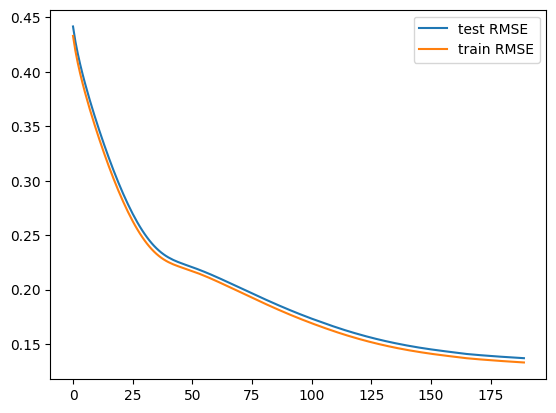

In [22]:
plt.plot(np.arange(len(test_loss)), test_loss)
plt.plot(np.arange(len(train_loss)), train_loss)
plt.legend(['test RMSE', 'train RMSE'])
plt.show()

In [25]:
initial_params.items()

dict_items([('tt', tensor([[[-0.0069, -0.0064, -0.0120, -0.0083,  0.0059,  0.0135, -0.0052,
           0.0183, -0.0010, -0.0090],
         [-0.0027, -0.0108,  0.0078, -0.0096, -0.0079,  0.0158,  0.0002,
          -0.0266,  0.0057, -0.0119],
         [ 0.0074,  0.0014,  0.0175,  0.0015, -0.0067, -0.0006, -0.0003,
          -0.0156,  0.0196,  0.0020],
         [-0.0077, -0.0021, -0.0054, -0.0092,  0.0095,  0.0019,  0.0105,
          -0.0017, -0.0234,  0.0043],
         [-0.0121,  0.0046,  0.0105,  0.0080,  0.0094, -0.0106,  0.0113,
           0.0052, -0.0005,  0.0005],
         [ 0.0007,  0.0071, -0.0013, -0.0154, -0.0063,  0.0122,  0.0034,
          -0.0016, -0.0104, -0.0111],
         [-0.0144, -0.0140, -0.0013, -0.0121,  0.0124, -0.0058, -0.0039,
           0.0122,  0.0036, -0.0009],
         [-0.0132, -0.0037,  0.0129, -0.0092,  0.0147,  0.0021,  0.0036,
          -0.0156, -0.0107,  0.0190],
         [-0.0064,  0.0084,  0.0097, -0.0002, -0.0012, -0.0143, -0.0069,
          -0.0056,  

In [26]:
updated_params = {name: param.clone().detach() for name, param in model.named_parameters()}
updated_params

{'tt': tensor([[[ 0.2749,  0.3895, -0.1203, -0.0286,  0.1626,  0.2750,  0.3194,
            0.1680, -0.0268,  0.3284],
          [ 0.2779,  0.2660, -0.1023, -0.3485, -0.0539,  0.2765,  0.4388,
            0.1048, -0.0212,  0.1856],
          [ 0.2935,  0.3160, -0.0924,  0.0058, -0.0341,  0.2688,  0.3243,
            0.0371, -0.1312,  0.1911],
          [-0.3205,  0.2757, -0.1157, -0.2605, -0.0431,  0.2652,  0.3410,
           -0.2122, -0.0528,  0.1946],
          [-0.2897,  0.2851,  0.1824, -0.0188, -0.0410,  0.2543,  0.3429,
            0.1902, -0.0296,  0.2612],
          [ 0.2894,  0.2825, -0.1120, -0.3840, -0.3989,  0.2733,  0.3341,
            0.2017, -0.0401,  0.1798],
          [-0.2968, -0.2945, -0.1121, -0.2276, -0.0377,  0.2578, -0.3973,
            0.2078, -0.0288,  0.2664],
          [ 0.4537,  0.4574, -0.1190,  0.4774,  0.4842,  0.4623,  0.4000,
            0.0272, -0.0499, -0.4668],
          [-0.1667, -0.0850,  0.2600, -0.2202, -0.2825, -0.2088, -0.4210,
           -0.42

In [27]:
# After training, you can get the updated parameters
updated_params = {name: param.clone().detach() for name, param in model.named_parameters()}

# # Calculate the difference between initial and updated parameters
# param_diff = {name: updated - initial for name, (updated, initial) in zip(updated_params.items(), initial_params.items())}

# Print the difference
for name, updated in updated_params.items():
    print(name)
    print(updated - initial_params[name])

tt
tensor([[[ 0.2818,  0.3959, -0.1083, -0.0204,  0.1567,  0.2616,  0.3245,
           0.1497, -0.0259,  0.3374],
         [ 0.2806,  0.2768, -0.1100, -0.3389, -0.0460,  0.2607,  0.4386,
           0.1314, -0.0268,  0.1975],
         [ 0.2861,  0.3147, -0.1100,  0.0043, -0.0273,  0.2694,  0.3246,
           0.0527, -0.1509,  0.1891],
         [-0.3128,  0.2778, -0.1103, -0.2513, -0.0525,  0.2634,  0.3305,
          -0.2105, -0.0295,  0.1903],
         [-0.2776,  0.2804,  0.1719, -0.0268, -0.0504,  0.2649,  0.3316,
           0.1850, -0.0291,  0.2607],
         [ 0.2887,  0.2753, -0.1107, -0.3686, -0.3926,  0.2611,  0.3307,
           0.2033, -0.0297,  0.1909],
         [-0.2824, -0.2806, -0.1108, -0.2155, -0.0501,  0.2636, -0.3934,
           0.1956, -0.0324,  0.2674],
         [ 0.4670,  0.4611, -0.1319,  0.4866,  0.4695,  0.4602,  0.3964,
           0.0428, -0.0392, -0.4857],
         [-0.1603, -0.0934,  0.2503, -0.2200, -0.2812, -0.1945, -0.4142,
          -0.4149,  0.0490, -0.2165]

In [11]:
model.mean

Parameter containing:
tensor([[[0.6410, 0.6174, 0.5814, 0.6638, 0.6117, 0.6094, 0.6586, 0.4364,
          0.6279, 0.7295],
         [0.1325, 0.1559, 0.1239, 0.1037, 0.1345, 0.1875, 0.1164, 0.8497,
          0.1221, 0.0154],
         [0.6748, 0.8704, 0.5587, 0.5842, 0.5559, 0.7428, 0.4122, 0.3030,
          0.9047, 0.7160],
         [0.0683, 0.0185, 0.1342, 0.1531, 0.0134, 0.0934, 0.1011, 0.1187,
          0.1211, 0.0308],
         [0.1616, 0.0740, 0.0206, 0.1170, 0.0072, 0.1495, 0.1282, 0.1107,
          0.0297, 0.0262],
         [0.0472, 0.0062, 0.0081, 0.0072, 0.0038, 0.0820, 0.1171, 0.0870,
          0.0266, 0.0079],
         [0.0851, 0.0786, 0.0226, 0.1177, 0.0078, 0.1548, 0.1832, 0.1156,
          0.0291, 0.0266],
         [0.1370, 0.1361, 0.3303, 0.1212, 0.1117, 0.0791, 0.5772, 0.1346,
          0.3753, 0.3439],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0275, 0.0000, 0.0000, 0.2500,
          0.0000, 0.0000]]], device='cuda:0', requires_grad=True)

In [12]:
torch.tanh(model.tt)

tensor([[[ 0.0540,  0.0086,  0.2576,  0.0631, -0.2375,  0.0880,  0.0649,
          -0.1835,  0.1819,  0.3929],
         [ 0.0288,  0.0052,  0.2581,  0.1241, -0.1360, -0.0168,  0.0773,
          -0.2938,  0.2055,  0.3675],
         [ 0.1201,  0.1108,  0.2557,  0.0396, -0.1373,  0.1221,  0.1023,
          -0.0812,  0.2535,  0.1007],
         [ 0.0642,  0.2244, -0.2880,  0.2603, -0.1320, -0.0140,  0.0801,
           0.2918, -0.3309,  0.0981],
         [-0.2701,  0.0319,  0.2487,  0.0635, -0.1326, -0.0288,  0.0709,
          -0.0598,  0.3363,  0.0992],
         [ 0.0605, -0.3223,  0.2545,  0.3256,  0.3339, -0.0222,  0.1730,
          -0.1371,  0.2015,  0.1055],
         [ 0.0639,  0.0169,  0.2536,  0.0473, -0.1353, -0.0115,  0.2977,
          -0.0625,  0.2035,  0.1119],
         [ 0.4063,  0.4137,  0.3900, -0.3752, -0.3620,  0.4039,  0.3698,
          -0.0552,  0.1983,  0.1004],
         [-0.1365, -0.1465, -0.1281,  0.1688,  0.2160, -0.1853,  0.2016,
          -0.2460, -0.0747, -0.1770]]],

In [13]:
model.linear.weight

Parameter containing:
tensor([[-0.1411, -0.2141, -0.1732,  0.3634,  0.3036, -0.2089,  0.1833,  0.1590,
         -0.1143, -0.3055, -0.1742, -0.1046, -0.0032,  0.1968,  0.2547, -0.2594,
          0.2410,  0.1698, -0.1855, -0.0621, -0.1188, -0.1061,  0.1442,  0.3072,
          0.3861, -0.1700,  0.3528,  0.3661, -0.0469, -0.0058,  0.0410, -0.0772,
         -0.0267,  0.3429,  0.3900, -0.0061,  0.1928,  0.2621,  0.1212, -0.1419,
         -0.0203,  0.0143, -0.0183,  0.2443,  0.2795,  0.0762,  0.3867,  0.3654,
          0.0930, -0.0566, -0.2036, -0.1748, -0.2543,  0.0876,  0.0888, -0.2724,
          0.1161, -0.0843, -0.0505, -0.2507,  0.0103,  0.0570, -0.0373,  0.2519,
          0.3069,  0.0900,  0.2156,  0.1913,  0.1267, -0.0746,  0.2476,  0.2082,
          0.2056,  0.4475,  0.5033,  0.2675,  0.4738,  0.4668,  0.4035,  0.2548,
          0.1160, -0.0076,  0.1415,  0.3284,  0.2637,  0.0608,  0.1946,  0.2991,
          0.1320, -0.0074, -0.1493, -0.1307, -0.0944,  0.3386,  0.3563, -0.1576,
      

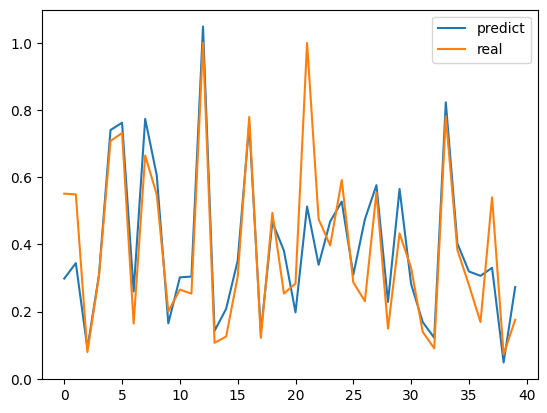

In [14]:
model.eval()
with torch.no_grad():
    plt.plot(np.array(model(X_test).to('cpu'))[40:80])
    plt.plot(y_test.cpu()[40:80])
    plt.legend(['predict', 'real'])

In [15]:
np.sqrt(mean_squared_error(np.array(model(X_test).detach().to('cpu')), y_test.cpu()))

0.13879618

IRIS = 94</br>
Cryotheraphy = 95</br>
Immunotherapy = 89</br>
Haberman = 74</br>
Wine = 89</br>
heart = 85</br>
CAL HOUSING : tsk:0.34, mamdani=0.33